# Assignment 1: EDA & Data Description of Fashion-MNIST
**· Performed by: Hứa Tuệ Minh (2450018)**

This notebook:
* Serves as **Part 1: Problem and Data Description** for the report.
* Covers the **Dataset description and EDA** section on the assignment page (GitHub Pages).
* Contributes to the **Problem & data understanding (15%)** criterion of Assignment 1.

Dataset: **Fashion-MNIST** is the primary dataset for all results. MNIST is solely for debugging, and CIFAR-10 is an optional extension (not used here).


conda activate dl-co3133

/opt/anaconda3/envs/dl-co3133/bin/python -m pip install numpy matplotlib torch torchvision

## 0. Setup
Import libraries, fix the random seed to 42, and create a directory for saving figures.

In [23]:
# 1. Standard library imports
import os #File paths and creating storage directories
from collections import Counter #Counting frequency of elements in a list

# 2. Computation and visualization libraries
import numpy as np  #For numerical operations
import matplotlib.pyplot as plt #Creating static plots

# 3. Deep learning libraries (PyTorch)
import torch
import torchvision
from torchvision import transforms #image preprocessing functions (like transforms.ToTensor(), transforms.Normalize()
from torch.utils.data import DataLoader #PyTorch's batch data loader

# 4. Fixed Seed (Reproducibility - the selected image sample indices and the data shuffling order remain 100% identical)
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
rng = np.random.default_rng(SEED)

# 5. Path Configuration and Automatic Directory Creation
DATA_ROOT = "../data"
OUT_DIR = "../reports/figures/eda_01"
#Checks if the directory exists; if not, it automatically creates it. 
#If it already exists, it skips the step without throwing an error.
os.makedirs(DATA_ROOT, exist_ok=True) 
os.makedirs(OUT_DIR, exist_ok=True)

# 6. Helper Function for Saving Figures
def savefig(name):
    path = os.path.join(OUT_DIR, name)
    plt.savefig(path, dpi=150, bbox_inches="tight")
    #image resolution and automatically crops excess whitespace around the chart
    print("saved:", path)

# 7. Environment Check
print("torch", torch.__version__, "| torchvision", torchvision.__version__)


torch 2.14.0 | torchvision 0.29.0


## 1. Load Fashion-MNIST
Download the original dataset from `torchvision.datasets` (60k train / 10k test). 

In [8]:
# 1. Load the Fashion-MNIST dataset for training and testing
train_set = torchvision.datasets.FashionMNIST(root=DATA_ROOT, train=True,  download=True)
test_set  = torchvision.datasets.FashionMNIST(root=DATA_ROOT, train=False, download=True)

# 2. Define the 10 class names for Fashion-MNIST
CLASS_NAMES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# 3. Extract image data (X) and labels (y)
X_train_full, y_train_full = train_set.data, train_set.targets  
X_test,       y_test       = test_set.data,  test_set.targets

# 4. Print the dataset shapes, data types, and pixel intensity range
# Raw pixel intensity: uint8 range 
print("Original train shape [N, H, W]:", tuple(X_train_full.shape), "| test shape:", tuple(X_test.shape))
print("Data type (dtype):", X_train_full.dtype, "| Pixel intensity range:", int(X_train_full.min()), "-", int(X_train_full.max()))

Original train shape [N, H, W]: (60000, 28, 28) | test shape: (10000, 28, 28)
Data type (dtype): torch.uint8 | Pixel intensity range: 0 - 255


**Observation:**
- Download Progress: The four "100.0%" outputs appear because the Fashion-MNIST dataset is stored on the server as four separate compressed files (training images, training labels, testing images, and testing labels).
- Image Data (X_train_full): Raw image tensor of shape [N, H, W]
- Label Data (y_train_full): Label tensor of shape [N], ground-truth targets y_i in {0, 1, ..., K-1}
- Color Channels: The channel dimension C = 1 (grayscale) is implicit in the raw uint8 data. Because it only has one channel, PyTorch loads it as a 3D tensor [N, H, W] rather than explicitly showing it as a 4D tensor [N, C, H, W]. 

## 2. Dataset Description (Handbook 3.1)
Source, version, license, number of samples, format, size, bias/limitations.

In [ ]:
# 1. Dataset description: 3D tensor [N, H, W]
n_train = X_train_full.shape[0]
n_test  = X_test.shape[0]
n_classes = len(CLASS_NAMES)

# 2. Actual storage size of the image tensors (uint8 = 1 byte/pixel)
# 1MB = 1024 KB = 1024 x 1024 bytes (RAM calculate by MB)
train_mb = X_train_full.numpy().nbytes / (1024**2)
test_mb  = X_test.numpy().nbytes / (1024**2)

print(f"Source       : Zalando Research (Fashion-MNIST)")
print(f"License      : MIT")
print(f"Classes      : {n_classes}")
print(f"Train images : {n_train:,}")
print(f"Test images  : {n_test:,}")
print(f"Image size   : 28 x 28, grayscale (1 channel)")
print(f"Data type    : {X_train_full.dtype} (pixel 0-255)")
print(f"Tensor size  : train ~{train_mb:.1f} MB, test ~{test_mb:.1f} MB")

Source       : Zalando Research (Fashion-MNIST)
License      : MIT
Classes      : 10
Train images : 60,000
Test images  : 10,000
Image size   : 28 x 28, grayscale (1 channel)
Data type    : torch.uint8 (pixel 0-255)
Tensor size  : train ~44.9 MB, test ~7.5 MB


**Observation:**
- Grayscale Color Loss (1 channel):The dataset completely lacks color information. This is a significant limitation, as color is a crucial feature for distinguishing and categorizing real-world clothing.
- Low Resolution (28 x 28): The extremely small image size means that fine details such as fabric textures, intricate patterns, and stitching are entirely discarded, simplifying the data far beyond real-world fashion imagery

## 3. Class Distribution from Original Data (Mandatory)
Count the number of images per class and plot the distribution for both the train & test sets (use class names, avoid 0–9).

saved: ../reports/figures/eda_01/class_distribution.png


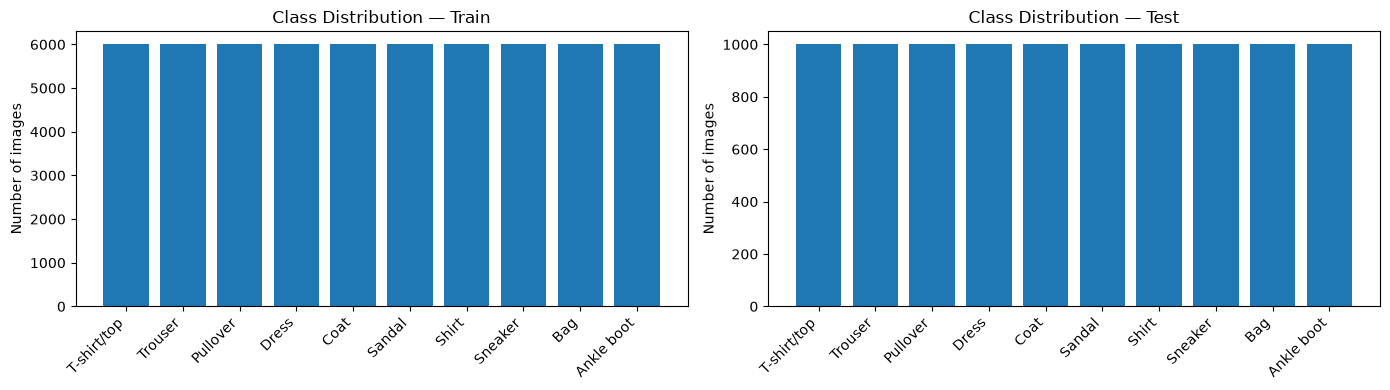

T-shirt/top : train=6000, test=1000
Trouser     : train=6000, test=1000
Pullover    : train=6000, test=1000
Dress       : train=6000, test=1000
Coat        : train=6000, test=1000
Sandal      : train=6000, test=1000
Shirt       : train=6000, test=1000
Sneaker     : train=6000, test=1000
Bag         : train=6000, test=1000
Ankle boot  : train=6000, test=1000


In [ ]:
# Count the number of images per class for the original train and test sets
def class_counts(y):
    c = Counter(y.tolist())
    return [c[i] for i in range(len(CLASS_NAMES))]

counts_train = class_counts(y_train_full)
counts_test  = class_counts(y_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, counts, title in [(axes[0], counts_train, "Train"), (axes[1], counts_test, "Test")]:
    ax.bar(range(len(CLASS_NAMES)), counts)
    ax.set_xticks(range(len(CLASS_NAMES)))
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
    ax.set_ylabel("Number of images")
    ax.set_title(f"Class Distribution - {title}")
plt.tight_layout()
savefig("class_distribution.png")
plt.show()

for name, ntr, nte in zip(CLASS_NAMES, counts_train, counts_test):
    print(f"{name:12s}: train={ntr}, test={nte}")

**Observation:**
- Even Distribution: Each of the 10 classes contains exactly 6,000 Train and 1,000 Test samples
- Reliable Metrics: Due to this perfect balance, Accuracy is a highly reliable metric

## 4. Input Size and Pixel Range (Mandatory)
Input tensor dimensions: height × width × number of channels; pixel value range.

In [18]:
# Single image properties
img = X_train_full[0]
print("Single image shape :", tuple(img.shape), "(H x W)")
print("Number of channels : 1 (grayscale)")
print("=> Input tensor    : [1, 28, 28]")
print("Flattened vector   :", img.numel(), "dimensions (784 = Linear/MLP input)")
print("Pixel dtype, range :", img.dtype, f"[{int(img.min())}, {int(img.max())}]")

Single image shape : (28, 28) (H x W)
Number of channels : 1 (grayscale)
=> Input tensor    : [1, 28, 28]
Flattened vector   : 784 dimensions (784 = Linear/MLP input)
Pixel dtype, range : torch.uint8 [0, 255]


## 5. Imbalance Analysis from Original Data (Mandatory)
Calculate the max/min sample ratio between classes to evaluate the degree of imbalance.

In [15]:
# Class imbalance check
imbalance_ratio = max(counts_train) / min(counts_train)
print("Samples per class (train):", counts_train)
print(f"Min = {min(counts_train)}, Max = {max(counts_train)}")
print(f"Imbalance ratio (max/min) = {imbalance_ratio:.4f}")

Samples per class (train): [6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]
Min = 6000, Max = 6000
Imbalance ratio (max/min) = 1.0000


**Observation:**
- Imbalance Ratio (1.0000): $\frac{\text{Max}}{\text{Min}} = \frac{6000}{6000} = 1.0000$ confirms perfect balance.
- Training Impact: Since no class bias exists, complex mitigation techniques like data resampling or weighted loss functions (Focal Loss) are entirely unnecessary

## 6. Representative Samples (Mandatory)
Display a few representative images for each class, using the class name as the title.

saved: ../reports/figures/eda_01/representative_samples.png


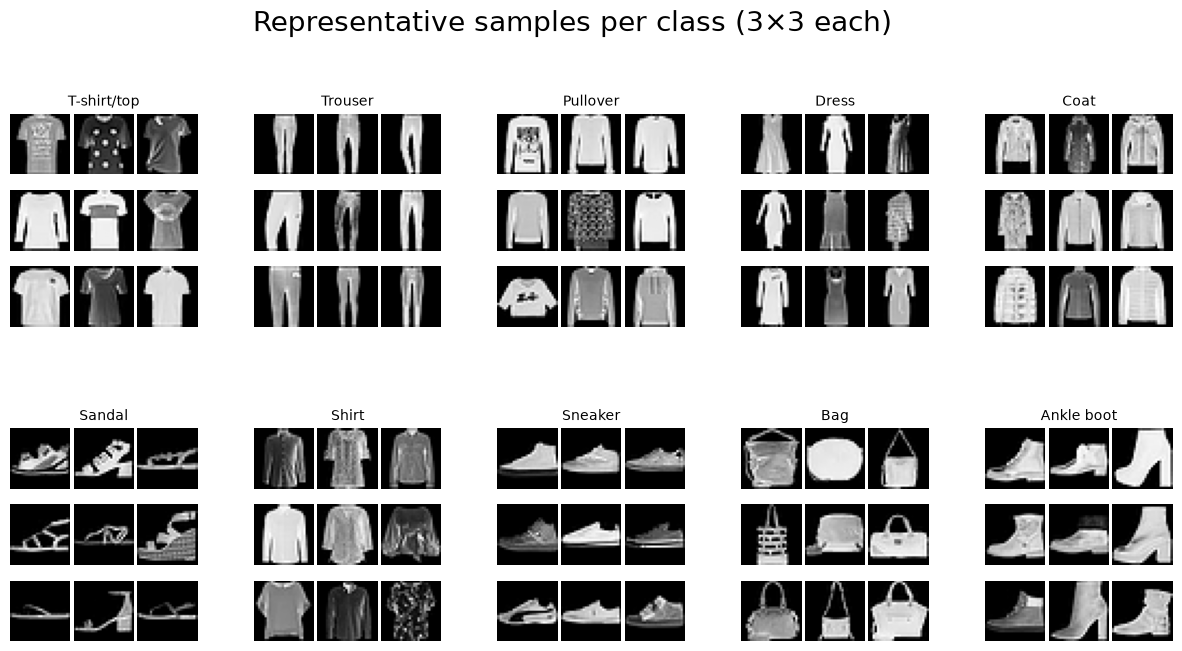

In [ ]:
N_ROWS, N_COLS = 3, 3          # 3x3 inner grid layout
N_PER_CLASS = N_ROWS * N_COLS  # 9 images per class

# 1. Create a large figure
fig = plt.figure(figsize=(15, 7))
# 2. Outer grid: 2 rows x 5 columns (for 10 classes) with margin spacing
outer = fig.add_gridspec(2, 5, wspace=0.3, hspace=0.4)

for cls in range(len(CLASS_NAMES)):
    # Get outer grid row (r) and col (c). Modulo 5 because there are 5 columns.
    r, c = divmod(cls, 5)
    
    # Nested 3x3 grid inside the current class cell (tight spacing)
    inner = outer[r, c].subgridspec(N_ROWS, N_COLS, wspace=0.05, hspace=0.05)

    # Get all image indices for this class and randomly pick 9 (without replacement)
    idxs = (y_train_full == cls).nonzero(as_tuple=True)[0].numpy()
    picks = rng.choice(idxs, size=N_PER_CLASS, replace=False)

    for i, k in enumerate(picks):
        # Calc inner row (i // cols) and inner col (i % cols), then add subplot
        ax = fig.add_subplot(inner[i // N_COLS, i % N_COLS])
        
        ax.imshow(X_train_full[k], cmap="gray") # Plot grayscale image
        ax.axis("off") # Hide axes for cleaner look
        
        # Place the class name above the top-middle image (index 1) of the 3x3 block
        if i == 1:
            ax.set_title(CLASS_NAMES[cls], fontsize=10)

# 3. Add global title, save to output directory, and display
plt.suptitle("Representative samples per class (3×3 each)", y=1.02, fontsize=20)
savefig("representative_samples.png")
plt.show()

**Observation:**

## 7. Data Splitting and Train / Validation / Test (Handbook 3.1)
Split the original training set (60k) into train/validation sets using a **stratified** approach (maintaining class proportions - 02 Datasets foundation slides), seed = 42; keep the original test set (10k) as the test set.  sẽ bổ sung thêm con số cụ thể dự kiến cho việc chia tập Train/Val 

*Clearly state:* splitting strategy, seed, stratification, splitting unit, and measures to prevent leakage.

*Fairness note:* This splitting logic will be transferred to `src/data/` so that all 5 models share the exact same split.

**Observation:**

## 8. Label Distribution by Set and Post-split Balance Check
Plot the class distribution for **all 3 sets** (train/val/test) to prove that the stratified split maintains balance (~10% per class in each set). This serves as evidence that the split does not skew the distribution.


**Observation:**

## 9. Preprocessing (Handbook 3.1)
Calculate mean/std **only on the training set after splitting** (to prevent leakage), build the `Normalize` transform, extract a preprocessed sample batch, and print its shape.

**Observation:**

## 10. Additional Analysis (Optional)
Pixel intensity histogram, mean image per class, this supports subsequent error analysis.

**Observation:**

## AI Usage Disclosure
- Hỗ trợ refine markdown bằng tiếng anh
